# Experiment 5 — When does a frequent pair become an SAE feature?

This experiment asks how common a particular composition must become before a
standard L1 SAE learns the composition instead of its reusable primitive
constituents. We hold `N=8` fixed because Experiment 3 recovered its 16 true
primitives almost perfectly under independent uniform pairing.

Only the dependence between feature identities changes. Every individual `x_i`
and `y_j` retains marginal probability `1/N`, so primitive frequency cannot explain
a transition from primitive to composed decoder directions.


## Fixed marginals and changing pair correlation

Let `pi(i)` be a fixed one-to-one matching from the `x` features to the `y`
features. Sampling first chooses `x_i` uniformly. With probability `rho`, its
matched partner `y_pi(i)` is selected; otherwise `y` is sampled independently and
uniformly. Therefore

$$P_\rho(x_i,y_j)=\frac{1-\rho}{N^2}+\frac{\rho}{N}\mathbf{1}[j=\pi(i)].$$

For every value of `rho`,

$$P(x_i)=P(y_j)=\frac1N.$$

The deliberately boosted composition has

$$P(y_{\pi(i)}\mid x_i)=\rho+\frac{1-\rho}{N},$$

while an unmatched pair has conditional probability `(1-rho)/N`. Thus `rho` is
the Pearson correlation between the binary occurrence indicators for `x_i` and its
matched `y_pi(i)`. This is identity/occurrence correlation, not amplitude
correlation; amplitudes remain equal within every example (`C=1`).


In [2]:
from __future__ import annotations

import json
import sys
from collections.abc import Iterator, Sequence
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from scipy.stats import rankdata


WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'toy_model.py').exists():
    EXPERIMENT_DIR = WORKING_DIR
elif (WORKING_DIR / 'composed-features' / 'toy_model.py').exists():
    EXPERIMENT_DIR = WORKING_DIR / 'composed-features'
else:
    raise FileNotFoundError(
        'Run from the repository root or composed-features directory.'
    )

if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from sae_lens import StandardTrainingSAE, StandardTrainingSAEConfig
from sae_lens.config import LoggingConfig, SAETrainerConfig
from sae_lens.training.sae_trainer import SAETrainer

from toy_model import default_device


DEVICE = default_device()
ARTIFACT_ROOT = EXPERIMENT_DIR / 'artifacts' / '05_pair_correlation'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'sae_checkpoints'
RESULTS_ROOT = ARTIFACT_ROOT / 'results'
for path in (CHECKPOINT_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

print('Experiment directory:', EXPERIMENT_DIR)
print('Device:', DEVICE)
print('Artifact root:', ARTIFACT_ROOT)


Experiment directory: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features
Device: mps
Artifact root: /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/05_pair_correlation


## Experimental controls

Every `rho` is an independent SAE training run because it defines a different data
distribution. Dictionary, data, matching, and SAE seeds remain fixed. Based on the
small seed variance at `N=8` and `N=256` in Experiment 3, this notebook uses one SAE
seed and concentrates compute on the correlation sweep.


In [3]:
N_PER_SET = 8
ACTIVATION_DIM = 8
D_SAE = 16
FULL_TRAINING_SAMPLES = 128_000_000
QUICK_TRAINING_SAMPLES = 262_144
TRAIN_BATCH_SIZE = 1_024
LEARNING_RATE = 3e-4
L1_COEFFICIENT = 0.3
ADAM_BETA1 = 0.0
ADAM_BETA2 = 0.999
DICTIONARY_SEED = 0
DATA_SEED = 0
PAIRING_SEED = 17
SAE_SEED = 0
EVAL_SEED = 10_000
EVAL_SAMPLES = 131_072
COSINE_THRESHOLD = 0.90

RHO_VALUES = (0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 1.0)
QUICK_RHO_VALUES = (0.0, 0.50, 1.0)
QUICK_MODE = False
RUN_EXPERIMENT = False

TRAINING_SAMPLES = (
    QUICK_TRAINING_SAMPLES if QUICK_MODE else FULL_TRAINING_SAMPLES
)
ACTIVE_RHO_VALUES = QUICK_RHO_VALUES if QUICK_MODE else RHO_VALUES

print('Quick mode:', QUICK_MODE)
print(f'Training samples per rho: {TRAINING_SAMPLES:,}')
print('Rho values:', ACTIVE_RHO_VALUES)
print(f'Independent SAE runs: {len(ACTIVE_RHO_VALUES)}')


Quick mode: False
Training samples per rho: 128,000,000
Rho values: (0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0)
Independent SAE runs: 7


In [4]:
probability_table = pd.DataFrame({
    'rho': ACTIVE_RHO_VALUES,
    'primitive_probability': [1 / N_PER_SET] * len(ACTIVE_RHO_VALUES),
    'matched_partner_given_x': [
        rho + (1 - rho) / N_PER_SET for rho in ACTIVE_RHO_VALUES
    ],
    'matched_pair_joint_probability': [
        rho / N_PER_SET + (1 - rho) / N_PER_SET**2
        for rho in ACTIVE_RHO_VALUES
    ],
    'each_unmatched_pair_joint_probability': [
        (1 - rho) / N_PER_SET**2 for rho in ACTIVE_RHO_VALUES
    ],
})
display(probability_table.style.format({
    'rho': '{:.2f}',
    'primitive_probability': '{:.3%}',
    'matched_partner_given_x': '{:.3%}',
    'matched_pair_joint_probability': '{:.3%}',
    'each_unmatched_pair_joint_probability': '{:.3%}',
}))


,rho,primitive_probability,matched_partner_given_x,matched_pair_joint_probability,each_unmatched_pair_joint_probability
0,0.00,12.500%,12.500%,1.562%,1.562%
1,0.10,12.500%,21.250%,2.656%,1.406%
2,0.25,12.500%,34.375%,4.297%,1.172%
3,0.50,12.500%,56.250%,7.031%,0.781%
4,0.75,12.500%,78.125%,9.766%,0.391%
5,0.90,12.500%,91.250%,11.406%,0.156%
6,1.00,12.500%,100.000%,12.500%,0.000%


## Ground-truth geometry and fixed-marginal sampler

The dictionary exactly follows Experiment 3: 16 primitive directions in 8
dimensions, organized as four antipodal `x` axes and four orthogonal antipodal `y`
axes, followed by a random orthogonal rotation. The matching `pi` is a fixed random
permutation, ensuring that every `y_j` receives exactly one correlated `x_i`.

For equal pair amplitudes, the exact matched-composition direction is

$$D_i^{comp}=\frac{D_{x_i}+D_{y_{\pi(i)}}}
{\lVert D_{x_i}+D_{y_{\pi(i)}}\rVert}. $$


In [5]:
def orthogonal_matrix(dim: int, seed: int) -> torch.Tensor:
    generator = torch.Generator(device='cpu').manual_seed(seed)
    matrix = torch.randn(dim, dim, generator=generator)
    q, r = torch.linalg.qr(matrix)
    signs = torch.where(torch.diag(r) >= 0, 1.0, -1.0)
    return q * signs.unsqueeze(0)


def make_antipodal_dictionary(
    n_per_set: int, *, seed: int, device: torch.device | str
) -> torch.Tensor:
    if n_per_set <= 0 or n_per_set % 2:
        raise ValueError('Antipodal geometry requires a positive, even N.')
    half = n_per_set // 2
    dictionary = torch.zeros(2 * n_per_set, n_per_set)
    for axis in range(half):
        dictionary[2 * axis, axis] = 1.0
        dictionary[2 * axis + 1, axis] = -1.0
        dictionary[n_per_set + 2 * axis, half + axis] = 1.0
        dictionary[n_per_set + 2 * axis + 1, half + axis] = -1.0
    return (dictionary @ orthogonal_matrix(n_per_set, seed)).to(device)


TRUE_DICTIONARY = make_antipodal_dictionary(
    N_PER_SET, seed=DICTIONARY_SEED, device=DEVICE
)
pairing_generator = torch.Generator(device='cpu').manual_seed(PAIRING_SEED)
MATCHED_Y = torch.randperm(
    N_PER_SET, generator=pairing_generator
).to(DEVICE)
MATCHED_COMPOSITIONS = F.normalize(
    TRUE_DICTIONARY[:N_PER_SET]
    + TRUE_DICTIONARY[N_PER_SET:][MATCHED_Y],
    dim=1,
)


class FixedMarginalPairGenerator:
    def __init__(
        self,
        rho: float,
        *,
        seed: int,
        device: torch.device | str,
    ) -> None:
        if not 0.0 <= rho <= 1.0:
            raise ValueError('rho must lie in [0, 1].')
        self.rho = float(rho)
        self.device = torch.device(device)
        self.rng = torch.Generator(device=self.device).manual_seed(seed)

    @torch.no_grad()
    def sample(self, batch_size: int) -> tuple[torch.Tensor, torch.Tensor]:
        if batch_size <= 0:
            raise ValueError('batch_size must be positive.')
        x_indices = torch.randint(
            N_PER_SET, (batch_size,), generator=self.rng, device=self.device
        )
        independent_y = torch.randint(
            N_PER_SET, (batch_size,), generator=self.rng, device=self.device
        )
        correlated = torch.rand(
            batch_size, generator=self.rng, device=self.device
        ) < self.rho
        y_indices = torch.where(
            correlated, MATCHED_Y[x_indices], independent_y
        )
        amplitudes = torch.rand(
            batch_size, generator=self.rng, device=self.device
        )

        coefficients = torch.zeros(
            batch_size, 2 * N_PER_SET, device=self.device
        )
        rows = torch.arange(batch_size, device=self.device)
        coefficients[rows, x_indices] = amplitudes
        coefficients[rows, N_PER_SET + y_indices] = amplitudes
        hidden = coefficients @ TRUE_DICTIONARY
        return hidden, coefficients


unit_dictionary = F.normalize(TRUE_DICTIONARY, dim=1)
assert torch.allclose(
    unit_dictionary[:N_PER_SET][0::2],
    -unit_dictionary[:N_PER_SET][1::2],
    atol=2e-5,
)
assert float((
    unit_dictionary[:N_PER_SET]
    @ unit_dictionary[N_PER_SET:].T
).abs().max()) < 2e-5
print('Matched y permutation:', MATCHED_Y.cpu().tolist())
print('Verified N=8 orthogonal-antipodal dictionary.')


Matched y permutation: [7, 0, 1, 5, 6, 4, 3, 2]
Verified N=8 orthogonal-antipodal dictionary.


In [6]:
@torch.no_grad()
def validate_sampler(rho: float, samples: int = 262_144) -> dict[str, float]:
    generator = FixedMarginalPairGenerator(
        rho, seed=1234, device=DEVICE
    )
    _, coefficients = generator.sample(samples)
    x = coefficients[:, :N_PER_SET].argmax(dim=1)
    y = coefficients[:, N_PER_SET:].argmax(dim=1)
    x_frequency = torch.bincount(x, minlength=N_PER_SET).float() / samples
    y_frequency = torch.bincount(y, minlength=N_PER_SET).float() / samples
    matched_fraction = float((y == MATCHED_Y[x]).float().mean())
    expected_matched = rho + (1 - rho) / N_PER_SET
    assert float((x_frequency - 1 / N_PER_SET).abs().max()) < 0.005
    assert float((y_frequency - 1 / N_PER_SET).abs().max()) < 0.005
    assert abs(matched_fraction - expected_matched) < 0.005
    return {
        'rho': rho,
        'max_x_marginal_error': float(
            (x_frequency - 1 / N_PER_SET).abs().max()
        ),
        'max_y_marginal_error': float(
            (y_frequency - 1 / N_PER_SET).abs().max()
        ),
        'observed_matched_partner_given_x': matched_fraction,
        'expected_matched_partner_given_x': expected_matched,
    }


sampler_checks = pd.DataFrame(
    [validate_sampler(rho) for rho in (0.0, 0.5, 1.0)]
)
display(sampler_checks.style.format(precision=5))


,rho,max_x_marginal_error,max_y_marginal_error,observed_matched_partner_given_x,expected_matched_partner_given_x
0,0.00000,0.00073,0.00088,0.12575,0.12500
1,0.50000,0.00073,0.00098,0.56222,0.56250
2,1.00000,0.00073,0.00073,1.00000,1.00000


## Independent SAE training runs

Each `rho` uses the same StandardTrainingSAE architecture and optimizer settings as
Experiment 3. Checkpoints are keyed by `rho`, seeds, sample budget, learning rate,
and L1 coefficient. The `rho=0` full-run condition reuses the completed Experiment 3
`N=8`, 128M, seed-0 checkpoint when available because it is exactly the same data
distribution and SAE configuration.


In [7]:
@dataclass(frozen=True)
class ExperimentSpec:
    rho: float
    training_samples: int = TRAINING_SAMPLES
    dictionary_seed: int = DICTIONARY_SEED
    data_seed: int = DATA_SEED
    pairing_seed: int = PAIRING_SEED
    sae_seed: int = SAE_SEED

    def slug(self) -> str:
        rho_slug = f'{self.rho:.2f}'.replace('.', 'p')
        return (
            f'N{N_PER_SET:04d}__rho-{rho_slug}'
            f'__dict-{self.dictionary_seed}__data-{self.data_seed}'
            f'__pair-{self.pairing_seed}__sae-{self.sae_seed}'
            f'__T-{self.training_samples}__lr-0p0003__l1-0p3'
        )


class ActivationIterator(Iterator[torch.Tensor]):
    def __init__(self, generator: FixedMarginalPairGenerator, batch_size: int):
        self.generator = generator
        self.batch_size = batch_size

    def __iter__(self):
        return self

    def __next__(self) -> torch.Tensor:
        hidden, _ = self.generator.sample(self.batch_size)
        return hidden.detach()


def make_sae(spec: ExperimentSpec) -> StandardTrainingSAE:
    torch.manual_seed(spec.sae_seed)
    config = StandardTrainingSAEConfig(
        d_in=ACTIVATION_DIM,
        d_sae=D_SAE,
        device=str(DEVICE),
        dtype='float32',
        apply_b_dec_to_input=False,
        normalize_activations='none',
        l1_coefficient=L1_COEFFICIENT,
        lp_norm=1.0,
        l1_warm_up_steps=0,
        decoder_init_norm=1.0,
    )
    return StandardTrainingSAE(config).to(DEVICE)


def make_trainer(
    spec: ExperimentSpec,
    sae: StandardTrainingSAE,
    generator: FixedMarginalPairGenerator,
) -> SAETrainer:
    config = SAETrainerConfig(
        total_training_samples=spec.training_samples,
        train_batch_size_samples=TRAIN_BATCH_SIZE,
        lr=LEARNING_RATE,
        lr_end=LEARNING_RATE,
        lr_scheduler_name='constant',
        lr_warm_up_steps=0,
        lr_decay_steps=0,
        adam_beta1=ADAM_BETA1,
        adam_beta2=ADAM_BETA2,
        device=str(DEVICE),
        n_checkpoints=0,
        checkpoint_path=None,
        save_final_checkpoint=False,
        logger=LoggingConfig(
            log_to_wandb=False, eval_every_n_wandb_logs=2**31 - 1
        ),
        n_batches_for_norm_estimate=1,
    )
    return SAETrainer(
        cfg=config,
        sae=sae,
        data_provider=ActivationIterator(generator, TRAIN_BATCH_SIZE),
    )


EXPERIMENT3_BASELINE = (
    EXPERIMENT_DIR
    / 'artifacts'
    / '03_sparse_factorial_antipodal'
    / 'sae_checkpoints'
    / 'N0008__g-antipodal__C-1p0__s-0p0__w-1p0__dict-0__data-0'
      '__sae-0__norm-0__T-128000000__lr-0p0003__l1-0p3'
)


def train_or_load_sae(
    spec: ExperimentSpec,
) -> tuple[StandardTrainingSAE, str]:
    run_dir = CHECKPOINT_ROOT / spec.slug()
    if (run_dir / 'cfg.json').exists() and (
        run_dir / 'sae_weights.safetensors'
    ).exists():
        sae = StandardTrainingSAE.load_from_disk(
            run_dir, device=str(DEVICE), dtype='float32'
        ).to(DEVICE)
        return sae, 'experiment_5_checkpoint'

    if (
        spec.rho == 0.0
        and spec.training_samples == FULL_TRAINING_SAMPLES
        and (EXPERIMENT3_BASELINE / 'cfg.json').exists()
        and (EXPERIMENT3_BASELINE / 'sae_weights.safetensors').exists()
    ):
        sae = StandardTrainingSAE.load_from_disk(
            EXPERIMENT3_BASELINE, device=str(DEVICE), dtype='float32'
        ).to(DEVICE)
        return sae, 'experiment_3_N8_baseline'

    generator = FixedMarginalPairGenerator(
        spec.rho, seed=spec.data_seed, device=DEVICE
    )
    sae = make_sae(spec)
    sae = make_trainer(spec, sae, generator).fit()
    run_dir.mkdir(parents=True, exist_ok=True)
    sae.save_model(run_dir)
    (run_dir / 'experiment_spec.json').write_text(
        json.dumps(asdict(spec), indent=2) + '\n'
    )
    return sae, 'new_training_run'


## Geometric and functional recovery metrics

Primitive recovery compares all 16 true primitive directions with all 16 learned
decoder directions using one-to-one Hungarian matching. Matched-composition recovery
compares the eight deliberately boosted equal-amplitude pair directions with eight
distinct learned decoders. Both report recovery at cosine 0.90 and MMCS.

Geometry alone only establishes that the SAE has an atom capable of writing a pair
direction. Functional validation therefore measures how well the geometrically
matched latent activation discriminates its exact `(x_i, y_pi(i))` pair from all
other examples using AUROC, along with positive and negative firing rates.


In [8]:
def recovery_against_targets(
    decoder: torch.Tensor, targets: torch.Tensor
) -> tuple[dict[str, float], torch.Tensor]:
    unit_decoder = F.normalize(decoder.detach().float(), dim=1)
    unit_targets = F.normalize(targets.detach().float(), dim=1)
    similarity = unit_targets @ unit_decoder.T
    target_rows, decoder_cols = linear_sum_assignment(
        -similarity.detach().cpu().numpy()
    )
    decoder_cols = torch.as_tensor(decoder_cols, device=similarity.device)
    assigned = similarity[
        torch.as_tensor(target_rows, device=similarity.device), decoder_cols
    ]
    return {
        'recovery_fraction_90': float(
            (assigned >= COSINE_THRESHOLD).float().mean()
        ),
        'mmcs': float(similarity.max(dim=1).values.mean()),
        'assigned_cosine_mean': float(assigned.mean()),
        'assigned_cosine_min': float(assigned.min()),
    }, decoder_cols


def binary_auroc(labels: np.ndarray, scores: np.ndarray) -> float:
    labels = labels.astype(bool)
    n_positive = int(labels.sum())
    n_negative = int((~labels).sum())
    if n_positive == 0 or n_negative == 0:
        return float('nan')
    ranks = rankdata(scores, method='average')
    rank_sum = float(ranks[labels].sum())
    return (
        rank_sum - n_positive * (n_positive + 1) / 2
    ) / (n_positive * n_negative)


@torch.no_grad()
def analyze_sae(
    spec: ExperimentSpec, sae: StandardTrainingSAE, checkpoint_source: str
) -> dict:
    primitive, _ = recovery_against_targets(sae.W_dec, TRUE_DICTIONARY)
    composition, composition_decoder_cols = recovery_against_targets(
        sae.W_dec, MATCHED_COMPOSITIONS
    )

    evaluation_generator = FixedMarginalPairGenerator(
        spec.rho, seed=EVAL_SEED, device=DEVICE
    )
    hidden, coefficients = evaluation_generator.sample(EVAL_SAMPLES)
    feature_acts = sae.encode(hidden)
    reconstructed = sae.decode(feature_acts)
    x_indices = coefficients[:, :N_PER_SET].argmax(dim=1)
    y_indices = coefficients[:, N_PER_SET:].argmax(dim=1)

    pair_aurocs = []
    positive_fire_rates = []
    negative_fire_rates = []
    for x_index in range(N_PER_SET):
        labels = (x_indices == x_index) & (
            y_indices == MATCHED_Y[x_index]
        )
        scores = feature_acts[:, composition_decoder_cols[x_index]]
        pair_aurocs.append(binary_auroc(
            labels.cpu().numpy(), scores.detach().cpu().numpy()
        ))
        fired = scores > 0
        positive_fire_rates.append(float(fired[labels].float().mean()))
        negative_fire_rates.append(float(fired[~labels].float().mean()))

    unit_decoder = F.normalize(sae.W_dec.detach().float(), dim=1)
    primitive_max = (
        unit_decoder @ F.normalize(TRUE_DICTIONARY, dim=1).T
    ).max(dim=1).values
    composition_max = (
        unit_decoder @ MATCHED_COMPOSITIONS.T
    ).max(dim=1).values
    primitive_atom = (primitive_max >= COSINE_THRESHOLD) & (
        primitive_max >= composition_max
    )
    composition_atom = (composition_max >= COSINE_THRESHOLD) & (
        composition_max > primitive_max
    )
    unclassified = ~(primitive_atom | composition_atom)

    squared_error = (hidden - reconstructed).pow(2).sum()
    total_variance = (hidden - hidden.mean(dim=0)).pow(2).sum()
    fired = feature_acts > 0
    matched_conditional = spec.rho + (1 - spec.rho) / N_PER_SET
    matched_joint = (
        spec.rho / N_PER_SET + (1 - spec.rho) / N_PER_SET**2
    )

    return {
        'rho': spec.rho,
        'primitive_probability': 1 / N_PER_SET,
        'matched_partner_given_x': matched_conditional,
        'matched_pair_joint_probability': matched_joint,
        'unmatched_pair_joint_probability': (1 - spec.rho) / N_PER_SET**2,
        'training_samples': spec.training_samples,
        'sae_seed': spec.sae_seed,
        'checkpoint_source': checkpoint_source,
        'primitive_recovery_fraction_90': primitive['recovery_fraction_90'],
        'primitive_mmcs': primitive['mmcs'],
        'primitive_assigned_cosine_mean': primitive['assigned_cosine_mean'],
        'composition_recovery_fraction_90': composition['recovery_fraction_90'],
        'composition_mmcs': composition['mmcs'],
        'composition_assigned_cosine_mean': composition['assigned_cosine_mean'],
        'pair_detection_auroc_mean': float(np.nanmean(pair_aurocs)),
        'pair_positive_fire_rate_mean': float(np.mean(positive_fire_rates)),
        'pair_negative_fire_rate_mean': float(np.mean(negative_fire_rates)),
        'decoder_primitive_fraction': float(primitive_atom.float().mean()),
        'decoder_matched_composition_fraction': float(
            composition_atom.float().mean()
        ),
        'decoder_unclassified_fraction': float(unclassified.float().mean()),
        'eval_fvu': float(squared_error / total_variance),
        'eval_mean_l0': float(fired.sum(dim=1).float().mean()),
        'eval_mean_l1': float(feature_acts.abs().sum(dim=1).mean()),
        'eval_dead_latent_fraction': float(
            (~fired.any(dim=0)).float().mean()
        ),
    }


## Run or load the sweep

Set `RUN_EXPERIMENT=True` deliberately. Start with `QUICK_MODE=True` to verify the
pipeline. In full mode, six new 128M-sample SAEs are required if the existing
Experiment 3 `rho=0` checkpoint is reused. Results are saved after every `rho`.


In [10]:
RUN_EXPERIMENT = True
QUICK_MODE, RUN_EXPERIMENT

(False, True)

In [11]:
run_label = 'quick' if QUICK_MODE else 'full_128m'
results_path = RESULTS_ROOT / f'pair_correlation_{run_label}.csv'
specs = [ExperimentSpec(rho=rho) for rho in ACTIVE_RHO_VALUES]

if RUN_EXPERIMENT:
    completed = {}
    if results_path.exists():
        saved = pd.read_csv(results_path)
        completed = {round(float(row['rho']), 8): row for row in (
            saved.to_dict(orient='records')
        )}

    for index, spec in enumerate(specs, start=1):
        key = round(spec.rho, 8)
        if key in completed:
            print(f'[{index}/{len(specs)}] Reused result row for rho={spec.rho:.2f}')
            continue
        print(f'[{index}/{len(specs)}] rho={spec.rho:.2f}')
        sae, source = train_or_load_sae(spec)
        completed[key] = analyze_sae(spec, sae, source)
        progress = pd.DataFrame([
            completed[round(item.rho, 8)]
            for item in specs
            if round(item.rho, 8) in completed
        ])
        progress.to_csv(results_path, index=False)
        del sae
        if DEVICE.type == 'mps':
            torch.mps.empty_cache()
        elif DEVICE.type == 'cuda':
            torch.cuda.empty_cache()

    results = pd.read_csv(results_path).sort_values('rho').reset_index(drop=True)
elif results_path.exists():
    results = pd.read_csv(results_path).sort_values('rho').reset_index(drop=True)
    print('Loaded', results_path)
else:
    results = None
    print('No results yet. Set RUN_EXPERIMENT=True after reviewing the setup.')

if results is not None:
    display(results.style.format(precision=4))


[1/7] rho=0.00
[2/7] rho=0.10


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

[3/7] rho=0.25


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

[4/7] rho=0.50


...

[6/7] rho=0.90


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

[7/7] rho=1.00


Training SAE:   0%|          | 0/128000000 [00:00<?, ?it/s]

,rho,primitive_probability,matched_partner_given_x,matched_pair_joint_probability,unmatched_pair_joint_probability,training_samples,sae_seed,checkpoint_source,primitive_recovery_fraction_90,primitive_mmcs,primitive_assigned_cosine_mean,composition_recovery_fraction_90,composition_mmcs,composition_assigned_cosine_mean,pair_detection_auroc_mean,pair_positive_fire_rate_mean,pair_negative_fire_rate_mean,decoder_primitive_fraction,decoder_matched_composition_fraction,decoder_unclassified_fraction,eval_fvu,eval_mean_l0,eval_mean_l1,eval_dead_latent_fraction
0,0.0000,0.1250,0.1250,0.0156,0.0156,128000000,0,experiment_3_N8_baseline,1.0000,1.0000,1.0000,0.0000,0.7079,0.7079,0.8772,0.8482,0.0938,1.0000,0.0000,0.0000,0.0608,1.6977,0.6932,0.0000
1,0.1000,0.1250,0.2125,0.0266,0.0141,128000000,0,new_training_run,1.0000,0.9997,0.9997,0.0000,0.7237,0.7237,0.8802,0.8472,0.0860,1.0000,0.0000,0.0000,0.0610,1.6982,0.7006,0.0000
2,0.2500,0.1250,0.3438,0.0430,0.0117,128000000,0,new_training_run,1.0000,0.9981,0.9981,0.0000,0.7502,0.7502,0.8867,0.8482,0.0727,1.0000,0.0000,0.0000,0.0617,1.7015,0.7036,0.0000
3,0.5000,0.1250,0.5625,0.0703,0.0078,128000000,0,new_training_run,1.0000,0.9889,0.9889,0.0000,0.8050,0.8050,0.8998,0.8535,0.0507,1.0000,0.0000,0.0000,0.0642,1.7155,0.6850,0.0000
4,0.7500,0.1250,0.7812,0.0977,0.0039,128000000,0,new_training_run,0.3125,0.8074,0.7635,1.0000,0.9798,0.9798,0.9322,0.8866,0.0404,0.2500,0.4375,0.3125,0.0794,1.4627,0.5752,0.0000
5,0.9000,0.1250,0.9125,0.1141,0.0016,128000000,0,new_training_run,0.0000,0.7219,0.6868,1.0000,0.9978,0.9978,0.9404,0.8895,0.0175,0.0000,0.5625,0.4375,0.0485,1.1925,0.5649,0.0000
6,1.0000,0.1250,1.0000,0.1250,0.0000,128000000,0,new_training_run,0.0000,0.7094,0.6377,1.0000,1.0000,1.0000,0.9464,0.8928,0.0000,0.0000,0.6875,0.3125,0.0314,1.2259,0.5807,0.3125


## Transition summary

This compact table expresses the intervention in three equivalent ways: `rho`, the
conditional prevalence of the matched partner, and the joint frequency of each
boosted pair. It then places primitive recovery, composition recovery, and functional
pair detection side by side. The printed threshold is descriptive for this sweep; a
denser follow-up grid is required to localize a transition more precisely.


In [12]:
if results is not None:
    transition_columns = [
        'rho',
        'matched_partner_given_x',
        'matched_pair_joint_probability',
        'primitive_recovery_fraction_90',
        'composition_recovery_fraction_90',
        'pair_detection_auroc_mean',
    ]
    transition_summary = results[transition_columns].copy()
    display(transition_summary.style.format({
        'rho': '{:.2f}',
        'matched_partner_given_x': '{:.1%}',
        'matched_pair_joint_probability': '{:.2%}',
        'primitive_recovery_fraction_90': '{:.3f}',
        'composition_recovery_fraction_90': '{:.3f}',
        'pair_detection_auroc_mean': '{:.3f}',
    }))

    majority_recovery = transition_summary.loc[
        transition_summary['composition_recovery_fraction_90'] >= 0.5
    ]
    if len(majority_recovery):
        first = majority_recovery.sort_values('rho').iloc[0]
        print(
            'First sampled point with at least 50% matched-composition recovery: '
            f'rho={first["rho"]:.2f}, '
            f'P(matched y | x)={first["matched_partner_given_x"]:.1%}, '
            f'P(each matched pair)={first["matched_pair_joint_probability"]:.2%}.'
        )
    else:
        print('No sampled rho achieved 50% matched-composition recovery.')


,rho,matched_partner_given_x,matched_pair_joint_probability,primitive_recovery_fraction_90,composition_recovery_fraction_90,pair_detection_auroc_mean
0,0.00,12.5%,1.56%,1.000,0.000,0.877
1,0.10,21.2%,2.66%,1.000,0.000,0.880
2,0.25,34.4%,4.30%,1.000,0.000,0.887
3,0.50,56.2%,7.03%,1.000,0.000,0.900
4,0.75,78.1%,9.77%,0.312,1.000,0.932
5,0.90,91.2%,11.41%,0.000,1.000,0.940
6,1.00,100.0%,12.50%,0.000,1.000,0.946


First sampled point with at least 50% matched-composition recovery: rho=0.75, P(matched y | x)=78.1%, P(each matched pair)=9.77%.


## Primitive-to-composition transition plots

The horizontal axis is the directly interpretable quantity
`P(y_pi(i) | x_i)`: the percentage of a primitive's contexts containing its matched
partner. The first two panels measure decoder geometry; the third validates pair
selectivity; the fourth checks reconstruction and sparsity.


Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/05_pair_correlation/results/pair_correlation_full_128m_recovery.png


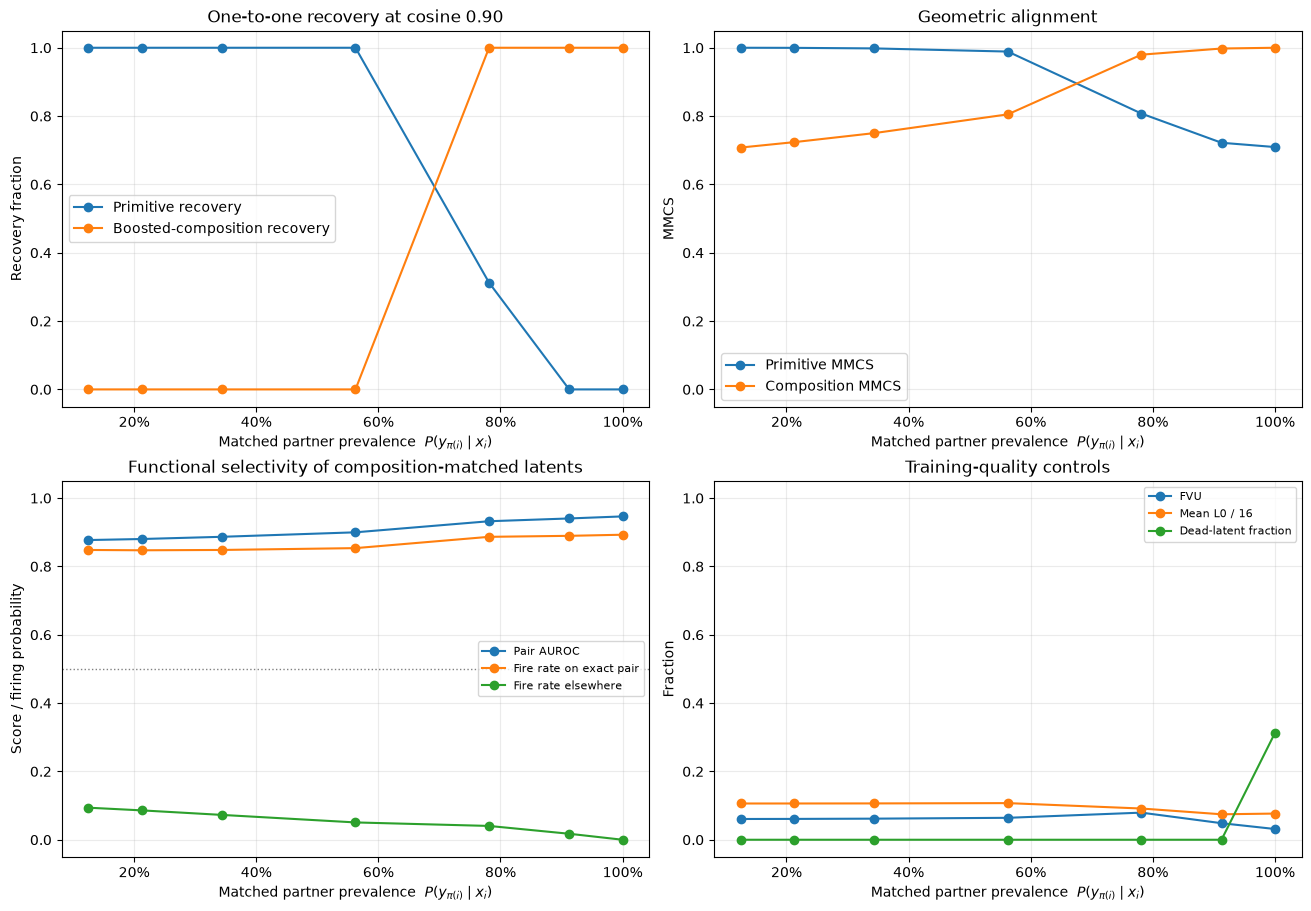

In [13]:
def format_probability_axis(ax):
    ax.set_xlabel(r'Matched partner prevalence  $P(y_{\pi(i)} \mid x_i)$')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{100*x:.0f}%'))
    ax.grid(alpha=0.25)


if results is not None:
    x = results['matched_partner_given_x']
    figure, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

    axes[0, 0].plot(
        x, results['primitive_recovery_fraction_90'], marker='o',
        label='Primitive recovery'
    )
    axes[0, 0].plot(
        x, results['composition_recovery_fraction_90'], marker='o',
        label='Boosted-composition recovery'
    )
    axes[0, 0].set(
        title='One-to-one recovery at cosine 0.90',
        ylabel='Recovery fraction', ylim=(-0.05, 1.05)
    )
    axes[0, 0].legend()
    format_probability_axis(axes[0, 0])

    axes[0, 1].plot(
        x, results['primitive_mmcs'], marker='o', label='Primitive MMCS'
    )
    axes[0, 1].plot(
        x, results['composition_mmcs'], marker='o', label='Composition MMCS'
    )
    axes[0, 1].set(title='Geometric alignment', ylabel='MMCS', ylim=(-0.05, 1.05))
    axes[0, 1].legend()
    format_probability_axis(axes[0, 1])

    axes[1, 0].plot(
        x, results['pair_detection_auroc_mean'], marker='o', label='Pair AUROC'
    )
    axes[1, 0].plot(
        x, results['pair_positive_fire_rate_mean'], marker='o',
        label='Fire rate on exact pair'
    )
    axes[1, 0].plot(
        x, results['pair_negative_fire_rate_mean'], marker='o',
        label='Fire rate elsewhere'
    )
    axes[1, 0].axhline(0.5, color='0.5', linestyle=':', linewidth=1)
    axes[1, 0].set(
        title='Functional selectivity of composition-matched latents',
        ylabel='Score / firing probability', ylim=(-0.05, 1.05)
    )
    axes[1, 0].legend(fontsize=8)
    format_probability_axis(axes[1, 0])

    axes[1, 1].plot(x, results['eval_fvu'], marker='o', label='FVU')
    axes[1, 1].plot(
        x, results['eval_mean_l0'] / D_SAE, marker='o',
        label='Mean L0 / 16'
    )
    axes[1, 1].plot(
        x, results['eval_dead_latent_fraction'], marker='o',
        label='Dead-latent fraction'
    )
    axes[1, 1].set(
        title='Training-quality controls', ylabel='Fraction', ylim=(-0.05, 1.05)
    )
    axes[1, 1].legend(fontsize=8)
    format_probability_axis(axes[1, 1])

    recovery_plot_path = RESULTS_ROOT / f'pair_correlation_{run_label}_recovery.png'
    figure.savefig(recovery_plot_path, dpi=200, bbox_inches='tight')
    print('Saved', recovery_plot_path)
    plt.show()


Saved /Users/abdulhakeemadefioye/Desktop/SAE/composed-features/artifacts/05_pair_correlation/results/pair_correlation_full_128m_allocation.png


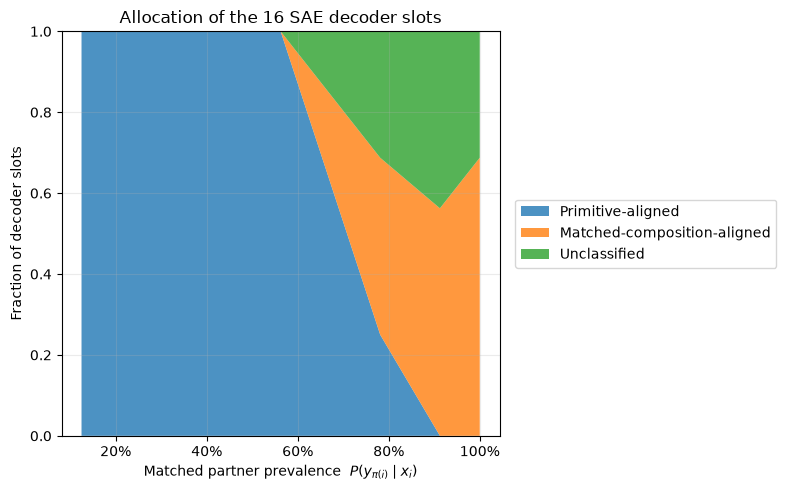

In [14]:
if results is not None:
    ordered = results.sort_values('matched_partner_given_x')
    x = ordered['matched_partner_given_x'].to_numpy()
    primitive_fraction = ordered['decoder_primitive_fraction'].to_numpy()
    composition_fraction = (
        ordered['decoder_matched_composition_fraction'].to_numpy()
    )
    unclassified_fraction = ordered['decoder_unclassified_fraction'].to_numpy()

    figure, axis = plt.subplots(figsize=(8, 5))
    axis.stackplot(
        x,
        primitive_fraction,
        composition_fraction,
        unclassified_fraction,
        labels=('Primitive-aligned', 'Matched-composition-aligned', 'Unclassified'),
        alpha=0.8,
    )
    axis.set(
        title='Allocation of the 16 SAE decoder slots',
        ylabel='Fraction of decoder slots',
        ylim=(0, 1),
    )
    format_probability_axis(axis)
    axis.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    figure.tight_layout()
    allocation_path = RESULTS_ROOT / f'pair_correlation_{run_label}_allocation.png'
    figure.savefig(allocation_path, dpi=200, bbox_inches='tight')
    print('Saved', allocation_path)
    plt.show()


## Interpretation checklist

1. Verify the displayed empirical `x` and `y` marginals remain uniform.
2. At `rho=0`, expect high primitive recovery and low recovery of the arbitrarily
   selected matched compositions.
3. Identify the first `rho`—and corresponding `P(y_pi(i)|x_i)`—where composition
   recovery, composition MMCS, decoder allocation, and pair AUROC rise together.
4. Check whether primitive recovery falls at the same point. A composition can be
   added before primitives disappear, but the 16-slot SAE cannot represent all 16
   primitives plus all eight matched compositions simultaneously.
5. Interpret geometric recovery only when pair AUROC and firing selectivity agree.
6. At `rho=1`, primitives are not separately identifiable from the data: each `x_i`
   only occurs with `y_pi(i)`. Composition recovery there is expected and does not
   by itself constitute an SAE failure.
7. Use FVU, L0, and dead-latent fraction to distinguish a representational switch
   from unsuccessful SAE training.

The experimental answer should be reported as a range, not an exact universal
constant: for example, 'under this N=8 geometry and SAE configuration, matched
compositions begin to be recovered when they appear in approximately X–Y% of each
constituent's contexts.' A denser rho sweep around the observed transition can then
refine that range.
